## Model Comparison Summary

| Model | Accuracy | Churn Precision | Churn Recall | Churn F1 |
|---|---|---|---|---|
| Logistic Regression (Tuned) | 75% | 0.53 | 0.46 | 0.49 |
| Random Forest (Base) | 78% | 0.57 | 0.69 | 0.63 |
| Random Forest (Tuned v1) | 73% | 0.49 | 0.79 | 0.61 |
| Random Forest (Tuned v2) | 77% | 0.55 | 0.71 | 0.62 |
| XGBoost (Base) | 80% | 0.64 | 0.54 | 0.58 |
| XGBoost (Weighted) | 75% | 0.53 | 0.74 | 0.61 |
| XGBoost (Tuned) ✅ | 75% | 0.52 | 0.81 | 0.63 |

> **Selected Model:** XGBoost Tuned — highest churn recall (0.81) with balanced F1 (0.63)  
> **Business Reasoning:** In telecom, missing a churner is more costly than a false retention effort

**Selected Model Parameters:**
| Parameter | Value |
|---|---|
| n_estimators | 100 |
| max_depth | 3 |
| learning_rate | 0.1 |
| scale_pos_weight | 2.77 |
| random_state | 42 |

In [62]:
# dependencies
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

In [32]:
ROOT = Path.cwd().parent
df = pd.read_csv(ROOT / 'data' / 'processed' / 'Telco_customer_churn_processed.csv')
df.head()

,CustomerID,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,Los Angeles,Male,No,No,No,2,Yes,No,DSL,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,Los Angeles,Female,No,No,Yes,2,Yes,No,Fiber optic,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,Los Angeles,Female,No,No,Yes,8,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,Los Angeles,Male,No,No,Yes,49,Yes,Yes,Fiber optic,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [33]:
df.columns

Index(['CustomerID', 'City', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines',
       'Internet Service', 'Online Security', 'Online Backup',
       'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies',
       'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges',
       'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV',
       'Churn Reason'],
      dtype='str')

Note: This experiment was run independently to test City's impact.

Final model below uses City dropped from the beginning of the pipeline.

In [ ]:
# Columns dropped before modeling — full reasoning in EDA and cleaning notebook:
# - CustomerID: unique identifier, not a predictive feature
# - Churn Score: derived metric, causes data leakage
# - CLTV: derived metric, causes data leakage  
# - Churn Reason: not available at prediction time, causes leakage
# - Churn Label: redundant, Churn Value (0/1) used as target variable

df_model = df.drop(columns=[
    'CustomerID',  
    'Churn Score', 
    'CLTV', 
    'Churn Reason', 
    'Churn Label',]
)

In [35]:
X = df_model.drop('Churn Value', axis=1)
y = df_model['Churn Value']

In [36]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:
# Verify the split
print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

print("Training labels  :", y_train.shape)
print("Testing labels   :", y_test.shape)

Training features: (5634, 19)
Testing features : (1409, 19)
Training labels  : (5634,)
Testing labels   : (1409,)


In [38]:
# Label Encoding for binary category
binary_cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 
    'Phone Service', 'Paperless Billing', 'Online Security',
    'Online Backup', 'Device Protection', 'Tech Support',
    'Streaming TV', 'Streaming Movies', 'Multiple Lines'
]

# Label Encoding for binary columns
le = LabelEncoder()

for col in binary_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])


# One Hot Encoding — for multi-category columns
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns — ensure train and test have same features
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

## Logistic Regression

In [ ]:
# Scaling features for Logistic Regression — lbfgs solver requires normalized input to converge
# fit_transform on X_train: learns mean and std from training data only
# transform on X_test: applies same scaling learned from training data — prevents data leakage
# Note: Scaling not required for tree based models (Random Forest, XGBoost)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced', solver='lbfgs')
lr.fit(X_train_scaled, y_train)
print("Done")

Done


In [46]:
y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83      1035
           1       0.53      0.46      0.49       374

    accuracy                           0.75      1409
   macro avg       0.67      0.66      0.66      1409
weighted avg       0.74      0.75      0.74      1409

[[883 152]
 [202 172]]


- Logistic Regression achieves a churn F1 of 0.49 and recall of 0.46 — missing over half of actual churners
- The low recall indicates the model struggles to capture the non-linear relationships in this dataset
- Logistic Regression will be used as a baseline reference only — Random Forest and XGBoost are explored further

## Random Forest

In [47]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.81      0.85      1035
           1       0.57      0.69      0.63       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409



- Base Random Forest (F1: 0.63, Recall: 0.69) outperforms tuned Logistic Regression (F1: 0.49, Recall: 0.46)
- indicating that the churn problem is non-linear and tree based models are better suited for this dataset

In [48]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'class_weight': ['balanced']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'class_weight': 'balanced', 'max_depth': 10, 'n_estimators': 100}
0.6315835841740298


In [49]:
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1035
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.74      1409



In [50]:
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), params, cv=5, scoring='f1')
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 300}
0.6501197789121761


In [51]:
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_rf_tuned))

              precision    recall  f1-score   support

           0       0.88      0.79      0.84      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



- Random Forest tuning has plateaued around F1 0.62-0.63 for churn class
- Base Random Forest remains the best balanced performer with F1 0.63 and Recall 0.69
- Further tuning shows diminishing returns — moving to XGBoost for potential improvement

## XGBoost

In [53]:
# without weight balance
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.54      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [54]:
# with weight balance
xgb = XGBClassifier(random_state=42, scale_pos_weight=2.77)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.76      1409



In [58]:
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8],
    'scale_pos_weight': [2.77]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42), params, cv=5, scoring='f1', n_jobs=2, verbose=2)
grid_xgb.fit(X_train, y_train)
print(grid_xgb.best_params_)
print(grid_xgb.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 2.77, 'subsample': 0.8}
0.6537620450973887


In [59]:
y_pred_xgb_tuned = grid_xgb.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_xgb_tuned))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



### XGBoost — Without City Feature

In [64]:
X = X.drop(columns=['City'])

In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

binary_cols = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents', 
    'Phone Service', 'Paperless Billing', 'Online Security',
    'Online Backup', 'Device Protection', 'Tech Support',
    'Streaming TV', 'Streaming Movies', 'Multiple Lines'
]

le = LabelEncoder()

for col in binary_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])


X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)


In [73]:
xgb_final = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=2.77,
    random_state=42
)
xgb_final.fit(X_train, y_train)
y_pred = xgb_final.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



- Experiment: Removing City (1129 unique categories, high cardinality)
- Result: Churn recall marginally improved (0.80 → 0.81), F1 unchanged (0.63)
- Conclusion: City adds no meaningful predictive value and increases model complexity
- Decision: City permanently dropped from modeling pipeline

## Final Model

In [76]:
# Final XGBoost model using best parameters identified from GridSearchCV
# City dropped, scale_pos_weight set for class imbalance (5174/1869 = 2.77)
xgb_final = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    scale_pos_weight=2.77,
    random_state=42,
    verbosity=0
)
xgb_final.fit(X_train, y_train)
print('Done')

Done


## Final Model Evaluation

- XGBoost with tuned parameters achieves the best churn recall (0.81) — identifying 4 out of 5 churners
- Churn F1 of 0.63 matches Random Forest but with significantly better recall
- Low precision (0.52) is a known tradeoff — model is aggressive in flagging churners due to `scale_pos_weight`
- In a telecom business context, high recall is preferred over precision — missing a churner (lost revenue) is more costly than a false alarm (wasted retention effort)
- **Final selected model:** XGBoost with `learning_rate=0.1`, `max_depth=3`, `n_estimators=100`, `scale_pos_weight=2.77`

## Feature Importance

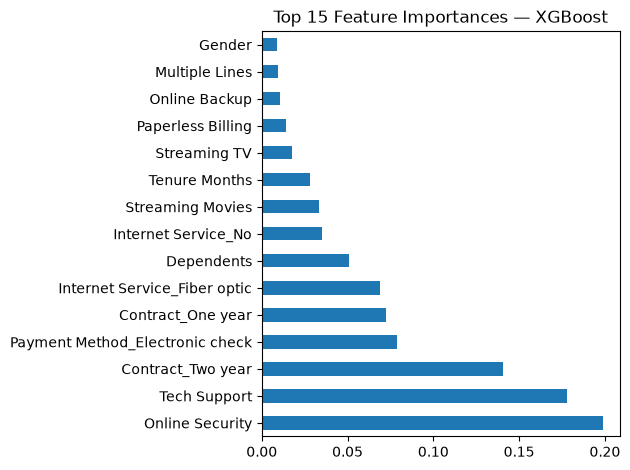

In [80]:
feat_imp = pd.Series(xgb_final.feature_importances_, index=X_train.columns)
feat_imp.sort_values(ascending=False).head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.savefig(ROOT / 'reports' / 'feature_importance.png', bbox_inches='tight')
plt.show()

### Feature Importance Analysis

Feature importance confirms and validates EDA findings:
- **Online Security** is the strongest predictor — customers without it churn at 41%
- **Contract type** (Two year, One year) are strong protectors against churn — long term commitment reduces risk
- **Tech Support** follows the same pattern as Online Security — lack of support leads to frustration and churn
- **Fiber optic** and **Electronic check** appear as expected — high cost service and disengaged payment method
- Weak EDA predictors (Multiple Lines, Partner, Streaming TV) rank lowest — consistent with EDA observations

> **Conclusion:** XGBoost model learned the same patterns identified during EDA, validating both the data exploration process and the final model selection

## Save Model

In [82]:
# Save the best model
models_dir = ROOT / 'models'
models_dir.mkdir(exist_ok=True)  # creates folder if it doesn't exist

joblib.dump(xgb_final, models_dir / 'xgb_churn_model.pkl')

print("Model saved successfully")

Model saved successfully
